# 05_a — Ablation: Recover Dropped Cells (Left Join)
## Change: left join from Wikipedia labels (185 cells instead of 149)

In [1]:
# ── CELL 0: Reproducibility ──────────────────────────────────────────────────
import random, os
import numpy as np
import torch

SEED = 20269999

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'mps'):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, 'manual_seed') else None
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'Global seed fixed: {SEED}')


Global seed fixed: 20269999


In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
TRAIN_CUTOFF    = '2025-01'
EXPERIMENT_NAME = '05_a_recovered_cells'

NEIGHBOR_RADIUS  = 1
FOCAL_OUT_WEIGHT = 0.0

NUM_EPOCHS    = 200
BATCH_SIZE    = 8
LEARNING_RATE = 1e-4
FREEZE_EPOCHS = 30
UNFREEZE_LR   = 1e-5

CHECKPOINT_EXP = f'{EXPERIMENT_NAME}/unet_a_best.pt'

print(f'Experiment      : {EXPERIMENT_NAME}')
print(f'Train cutoff    : {TRAIN_CUTOFF}')
print(f'Neighbor radius : {NEIGHBOR_RADIUS}')
print(f'Focal out wt    : {FOCAL_OUT_WEIGHT}')
print(f'Epochs          : {NUM_EPOCHS}')


Experiment      : 05_a_recovered_cells
Train cutoff    : 2025-01
Neighbor radius : 1
Focal out wt    : 0.0
Epochs          : 200


In [3]:
# ── CELL 1: Imports, Paths, Target Variable ───────────────────────────────────
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from scipy.ndimage import binary_dilation
import copy, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
REPORTS      = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR   = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

target = pd.read_parquet(DATA_PROC / '10_target_variable.parquet')
target['year_month'] = target['year_month'].astype(str)

print(f'Target rows: {len(target):,}  |  months: {target["year_month"].nunique()}'
      f'  |  cells: {target["priogrid_gid"].nunique()}')
print('\nClass distribution:')
print(target['target'].value_counts())


/Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target rows: 5,238  |  months: 29  |  cells: 185

Class distribution:
target
gov          3303
opo          1110
uncertain     825
Name: count, dtype: int64


In [4]:
# ── CELL 2: Build Raster Dataset  [05_a: left join from labels] ──────────────
# KEY CHANGE: left join FROM target (185 cells) rather than inner join.
# The 36 cells with Wikipedia labels but no UCDP events get 0.0 features
# BEFORE z-scoring → they correctly represent "genuinely quiet" areas.
from sklearn.preprocessing import LabelEncoder

features = pd.read_csv(DATA_PROC / 'myanmar_priogrid_features.csv')
features['year_month'] = features['year_month'].astype(str)

INPUT_FEATURES = [
    'total_events', 'total_fatalities', 'events_gov', 'events_nug',
    'events_ula', 'events_kio', 'gov_vs_civilians', 'gov_event_share',
    'total_events_lag1', 'total_fatalities_lag1',
]
NUM_CHANNELS = len(INPUT_FEATURES)

# PRIOGRID cell → (local_row, local_col) from UCDP feature cells ──────────────
def gid_to_rowcol(gid):
    return (gid - 1) // 720, (gid - 1) % 720

all_gids = features['priogrid_gid'].unique()
gid_coords = {}
for gid in all_gids:
    r, c = gid_to_rowcol(gid)
    gid_coords[gid] = {'global_row': r, 'global_col': c}
coords_df = pd.DataFrame.from_dict(gid_coords, orient='index')
coords_df.index.name = 'priogrid_gid'

min_global_row = coords_df['global_row'].min()
min_global_col = coords_df['global_col'].min()
coords_df['local_row'] = coords_df['global_row'] - min_global_row
coords_df['local_col'] = coords_df['global_col'] - min_global_col

RASTER_H = coords_df['local_row'].max() + 1
RASTER_W = coords_df['local_col'].max() + 1
PAD_H    = int(np.ceil(RASTER_H / 8) * 8)
PAD_W    = int(np.ceil(RASTER_W / 8) * 8)

# Base gid_to_local from UCDP cells
gid_to_local = coords_df[['local_row','local_col']].to_dict('index')

# ── Left join FROM labels (recover 36 dropped cells) ─────────────────────────
LABEL_MAP = {'gov': 0, 'opo': 1, 'uncertain': 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}

labelled = target[['priogrid_gid','year_month','target']].merge(
    features,
    on=['priogrid_gid','year_month'], how='left'
)
# Fill missing feature values with 0.0 BEFORE z-scoring
labelled[INPUT_FEATURES] = labelled[INPUT_FEATURES].fillna(0.0)
labelled['label_int'] = labelled['target'].map(LABEL_MAP)

# Expand gid_to_local to include recovered cells that fall within the raster
for gid in labelled['priogrid_gid'].unique():
    if gid in gid_to_local:
        continue
    r0, c0 = gid_to_rowcol(gid)
    lr = r0 - min_global_row
    lc = c0 - min_global_col
    if 0 <= lr < PAD_H and 0 <= lc < PAD_W:
        gid_to_local[gid] = {'local_row': lr, 'local_col': lc}

n_recovered = len(labelled['priogrid_gid'].unique()) - len(all_gids)
n_in_raster = sum(1 for g in labelled['priogrid_gid'].unique() if g in gid_to_local)
print(f'Left join: {labelled["priogrid_gid"].nunique()} unique cells'
      f'  ({n_recovered:+d} vs inner-join baseline)')
print(f'Cells mappable to raster: {n_in_raster}')

# Normalise on training statistics ONLY (fit on training months after NaN fill)
train_mask_rows = labelled['year_month'] <= TRAIN_CUTOFF
train_months_used = sorted(labelled.loc[train_mask_rows, 'year_month'].unique())
feat_means = labelled.loc[train_mask_rows, INPUT_FEATURES].mean()
feat_stds  = labelled.loc[train_mask_rows, INPUT_FEATURES].std().replace(0, 1)
print(f'\nNormalisation fit on {len(train_months_used)} training months:')
print(f'  {train_months_used[0]} → {train_months_used[-1]}')
labelled[INPUT_FEATURES] = (labelled[INPUT_FEATURES] - feat_means) / feat_stds

# Build monthly rasters
months_with_labels = sorted(labelled['year_month'].unique())
X_rasters, y_rasters, masks_r, month_keys = [], [], [], []

for month in months_with_labels:
    md_  = labelled[labelled['year_month'] == month]
    X_r  = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)
    y_r  = np.full( (PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
    msk  = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local: continue
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[INPUT_FEATURES].values
        y_r[lr, lc]    = row['label_int']
        msk[lr, lc]    = 1
    X_rasters.append(np.transpose(X_r, (2,0,1)))
    y_rasters.append(y_r); masks_r.append(msk); month_keys.append(month)

X_array = np.stack(X_rasters); y_array = np.stack(y_rasters); m_array = np.stack(masks_r)

train_idx = [i for i, m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx   = [i for i, m in enumerate(month_keys) if m >  TRAIN_CUTOFF]
X_train, y_train, m_train = X_array[train_idx], y_array[train_idx], m_array[train_idx]
X_val,   y_val,   m_val   = X_array[val_idx],   y_array[val_idx],   m_array[val_idx]
val_month_keys = [month_keys[i] for i in val_idx]

print(f'Raster shape: {X_array.shape}  (months x channels x H x W)')
print(f'Avg labelled cells/month: {m_array.sum(axis=(1,2)).mean():.0f}')
print(f'Train months: {len(train_idx)}  ({month_keys[train_idx[0]]} → {month_keys[train_idx[-1]]})')
print(f'Val   months: {len(val_idx)}   ({month_keys[val_idx[0]]} → {month_keys[val_idx[-1]]})')


Left join: 185 unique cells  (-14 vs inner-join baseline)
Cells mappable to raster: 183

Normalisation fit on 15 training months:
  2023-11 → 2025-01
Raster shape: (29, 10, 40, 16)  (months x channels x H x W)
Avg labelled cells/month: 179
Train months: 15  (2023-11 → 2025-01)
Val   months: 14   (2025-02 → 2026-03)


Total labelled cells      : 185
Cells that change label   : 94  (50.8%)
Cells always stable       : 91

── Focal Mask Statistics (radius=1) ──
  Focal mask pixels        : 285 / 640  (44.5% of raster)
  Avg labelled cells/month : 179
  Train cell-months in focal mask     : 2,243 / 2,618 (85.7%)
  Of those, cells that ever change    : 1,338 (59.7%)
  Gradient concentrated on: 2,243 cell-months (vs 2,618 in baseline)

Focal mask saved to: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_r1.npy


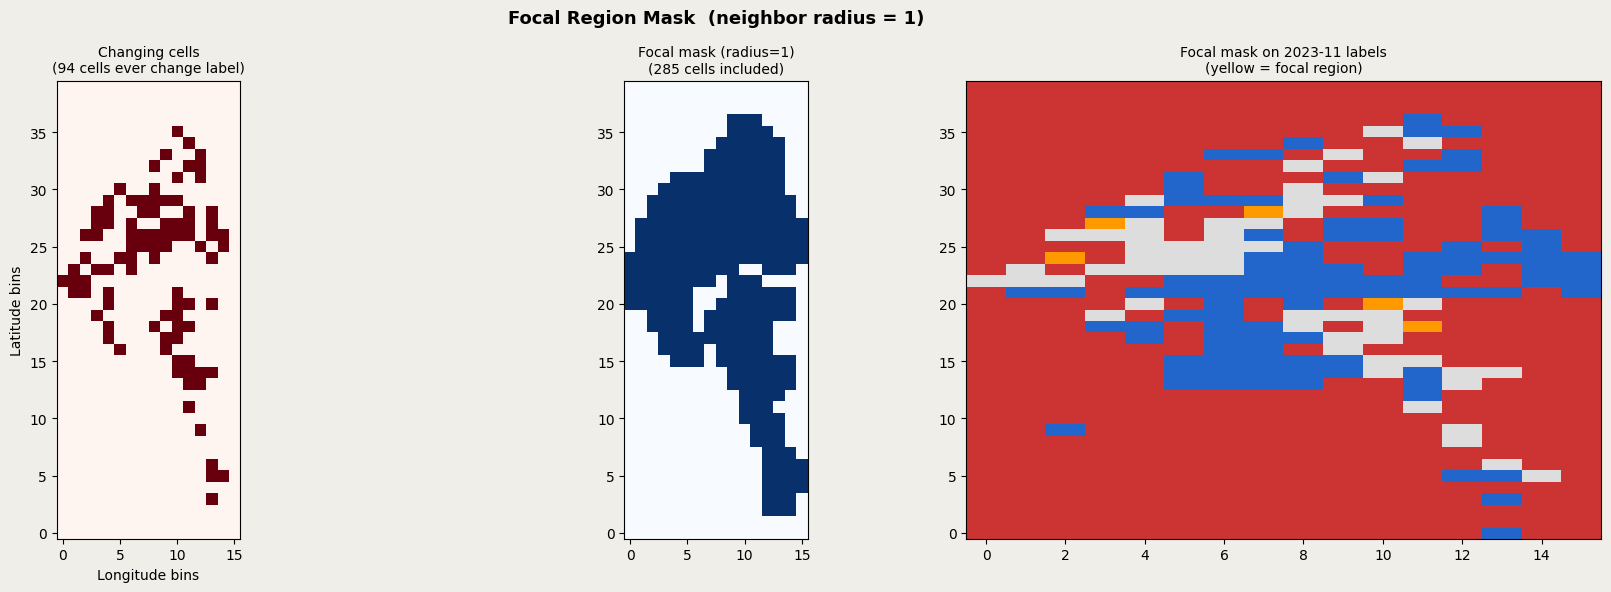

Focal mask figure saved.


In [5]:
# ── CELL 3: Build Focal Mask ─────────────────────────────────────────────────
# Identify which raster cells ever change control over the full 29-month panel,
# then dilate by NEIGHBOR_RADIUS to include spatial context.

# ── 3.1 Find changing cells ──────────────────────────────────────────────────
# A cell 'changes' if it has >= 2 distinct labels across all months.

label_by_gid = labelled.groupby('priogrid_gid')['label_int'].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index)

print(f'Total labelled cells      : {len(label_by_gid):,}')
print(f'Cells that change label   : {len(changing_gids):,}'
      f'  ({100*len(changing_gids)/len(label_by_gid):.1f}%)')
print(f'Cells always stable       : {len(label_by_gid) - len(changing_gids):,}')

# ── 3.2 Build binary raster of changing cells (PAD_H x PAD_W) ───────────────
changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster[lr, lc] = True

# ── 3.3 Dilate by NEIGHBOR_RADIUS (queen contiguity) ────────────────────────
# binary_dilation with a square structuring element includes all cells
# within NEIGHBOR_RADIUS steps in any direction (including diagonals).
struct = np.ones((2*NEIGHBOR_RADIUS+1, 2*NEIGHBOR_RADIUS+1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)  # (PAD_H, PAD_W) bool

# ── 3.4 Report coverage ──────────────────────────────────────────────────────
n_focal       = focal_mask_np.sum()
n_all_cells   = m_array.sum(axis=(1,2)).mean()  # avg labelled cells per month
n_total_px    = PAD_H * PAD_W

# Of all labelled cell-months in training, how many are in the focal region?
focal_mask_3d = focal_mask_np[np.newaxis, :, :]  # (1, H, W) broadcast
n_focal_labelled_train = int((m_train * focal_mask_3d).sum())
n_total_labelled_train = int(m_train.sum())

# Of those focal labelled train cell-months, what fraction actually changed?
# A 'change' cell-month is one where the cell is in changing_gids
changing_raster_labeled = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster_labeled[lr, lc] = 1

n_actual_change_train = int((m_train * changing_raster_labeled[np.newaxis]).sum())

print(f'\n── Focal Mask Statistics (radius={NEIGHBOR_RADIUS}) ──')
print(f'  Focal mask pixels        : {n_focal} / {n_total_px}'
      f'  ({100*n_focal/n_total_px:.1f}% of raster)')
print(f'  Avg labelled cells/month : {n_all_cells:.0f}')
print(f'  Train cell-months in focal mask     : {n_focal_labelled_train:,}'
      f' / {n_total_labelled_train:,}'
      f' ({100*n_focal_labelled_train/n_total_labelled_train:.1f}%)')
print(f'  Of those, cells that ever change    : {n_actual_change_train:,}'
      f' ({100*n_actual_change_train/max(n_focal_labelled_train,1):.1f}%)')
print(f'  Gradient concentrated on: {n_focal_labelled_train:,} cell-months'
      f' (vs {n_total_labelled_train:,} in baseline)')

# ── 3.5 Save mask to disk ────────────────────────────────────────────────────
mask_path = MODELS_DIR / f'focal_mask_r{NEIGHBOR_RADIUS}.npy'
np.save(mask_path, focal_mask_np)
print(f'\nFocal mask saved to: {mask_path}')

# ── 3.6 Visualise focal mask ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#F0EEE8')
fig.suptitle(f'Focal Region Mask  (neighbor radius = {NEIGHBOR_RADIUS})',
             fontsize=13, fontweight='bold')

# Panel 1: changing cells only
ax = axes[0]
ax.imshow(changing_raster.astype(float), cmap='Reds', origin='lower', vmin=0, vmax=1)
ax.set_title(f'Changing cells\n({len(changing_gids)} cells ever change label)', fontsize=10)
ax.set_xlabel('Longitude bins'); ax.set_ylabel('Latitude bins')

# Panel 2: focal mask (changing + neighbors)
ax = axes[1]
ax.imshow(focal_mask_np.astype(float), cmap='Blues', origin='lower', vmin=0, vmax=1)
ax.set_title(f'Focal mask (radius={NEIGHBOR_RADIUS})\n({n_focal} cells included)', fontsize=10)

# Panel 3: focal mask overlaid on a sample label raster
ax = axes[2]
label_cmap  = mcolors.ListedColormap(['#CC3333','#2266CC','#FF9900','#DDDDDD'])
label_bounds = [-1.5,-0.5,0.5,1.5,2.5]
label_norm   = mcolors.BoundaryNorm(label_bounds, label_cmap.N)
ax.imshow(y_train[0], cmap=label_cmap, norm=label_norm, origin='lower', aspect='auto')
# Overlay focal mask boundary
from matplotlib.colors import ListedColormap
overlay = np.ma.masked_where(~focal_mask_np, np.ones_like(focal_mask_np, dtype=float))
ax.imshow(overlay, cmap=ListedColormap(['none','yellow']), origin='lower',
          alpha=0.35, aspect='auto')
ax.set_title(f'Focal mask on {month_keys[train_idx[0]]} labels\n(yellow = focal region)', fontsize=10)

plt.tight_layout()
fig.savefig(REPORTS / f'focal_mask_r{NEIGHBOR_RADIUS}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Focal mask figure saved.')


In [6]:
# ── CELL 4: Model Architecture and Loss Functions ────────────────────────────

# ── 4.1 Device ───────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

# ── 4.2 Hyperparameters ───────────────────────────────────────────────────────
NUM_CLASSES  = 3
ENCODER_NAME    = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'

# ── 4.3 Class weights (inverse frequency) ────────────────────────────────────
label_counts     = np.array([
    (labelled['label_int'] == 0).sum(),
    (labelled['label_int'] == 1).sum(),
    (labelled['label_int'] == 2).sum(),
])
class_weights_np     = len(labelled) / (NUM_CLASSES * label_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print(f'Class weights: gov={class_weights_np[0]:.3f}  opo={class_weights_np[1]:.3f}'
      f'  uncertain={class_weights_np[2]:.3f}')

# ── 4.4 Dice loss (shared by both loss functions) ────────────────────────────
dice_loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True, smooth=1.0)

# ── 4.5 Baseline combined loss (same as notebook 03) ─────────────────────────
def combined_loss(predictions, targets, mask):
    """CE + Dice on all labelled cells (no focal masking)."""
    safe_targets = targets.clone()
    safe_targets[mask == 0] = 0

    preds_hwc   = predictions.permute(0,2,3,1)      # (B,H,W,C)
    valid_preds = preds_hwc[mask == 1]               # (N, C)
    valid_tgts  = targets[mask == 1]                 # (N,)

    if valid_preds.shape[0] == 0:
        return torch.tensor(0.0, requires_grad=True, device=predictions.device)

    ce = F.cross_entropy(valid_preds, valid_tgts, weight=class_weights_tensor)
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc


# ── 4.6 Focal combined loss ───────────────────────────────────────────────────
# Key design:
#   CE   — per-pixel, weighted by (label_mask AND focal_mask).
#          Cells outside the focal region contribute weight FOCAL_OUT_WEIGHT to CE.
#   Dice — applied to the full labelled region (preserves spatial shape signal).
# The full-raster prediction still flows through the encoder; only the CE gradient
# is concentrated. This is different from zeroing out predictions before the loss.

# Pre-compute the focal mask tensor once (static across all epochs)
focal_mask_tensor = torch.from_numpy(focal_mask_np).bool().to(DEVICE)  # (H, W)

def focal_combined_loss(predictions, targets, label_mask):
    """
    CE + Dice where CE is weighted by focal_mask.
    predictions : (B, C, H, W)  logits
    targets     : (B, H, W)     int64 labels (-1 = no label)
    label_mask  : (B, H, W)     uint8, 1=labelled
    """
    B = predictions.shape[0]

    # pixel weight: (B, H, W) — in-focal + labelled gets 1.0, out-of-focal + labelled
    # gets FOCAL_OUT_WEIGHT, unlabelled always 0.
    focal_broad = focal_mask_tensor.unsqueeze(0).expand(B, -1, -1)  # (B, H, W)
    pixel_w = torch.where(
        focal_broad,
        label_mask.float(),                         # focal cells: full weight if labelled
        label_mask.float() * FOCAL_OUT_WEIGHT,      # non-focal: reduced weight if labelled
    )  # (B, H, W)

    # CE per-pixel (reduction='none') using class weights via manual computation
    safe_targets = targets.clone()
    safe_targets[label_mask == 0] = 0  # dummy class for unlabelled (masked out by pixel_w)

    ce_per_pixel = F.cross_entropy(
        predictions, safe_targets,
        weight=class_weights_tensor,
        reduction='none',
    )  # (B, H, W)

    n_effective = pixel_w.sum() + 1e-8
    ce = (ce_per_pixel * pixel_w).sum() / n_effective

    # Dice: full labelled region (spatial shape signal; no focal restriction)
    dc = dice_loss_fn(predictions, safe_targets)

    return 0.5 * ce + 0.5 * dc


# ── 4.7 Model factory ─────────────────────────────────────────────────────────
def build_model():
    """Fresh U-Net with same seed — call before each training run."""
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    m = smp.Unet(
        encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
        in_channels=NUM_CHANNELS,  classes=NUM_CLASSES,
        activation=None, decoder_channels=(128,64,32,16), encoder_depth=4,
    ).to(DEVICE)
    return m

def build_optimizer(model):
    params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())
    opt = optim.Adam(params, lr=LEARNING_RATE, weight_decay=1e-5)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)
    return opt, sch

print('Loss functions and model factory defined.')


Device: mps
Class weights: gov=0.529  opo=1.573  uncertain=2.116
Loss functions and model factory defined.


In [7]:
# ── CELL 5: Dataset, DataLoader Helpers, and Training Loop ───────────────────

class MyanmarRasterDataset(Dataset):
    def __init__(self, X, y, mask, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.mask    = mask.astype(np.uint8)
        self.augment = augment
        self.T       = len(X)

    def __len__(self): return self.T

    def __getitem__(self, idx):
        X, y, mask = (torch.from_numpy(self.X[idx]),
                      torch.from_numpy(self.y[idx]),
                      torch.from_numpy(self.mask[idx]))
        if self.augment:
            if torch.rand(1).item() > 0.5:
                X, y, mask = (torch.flip(X,[2]), torch.flip(y,[1]), torch.flip(mask,[1]))
            if torch.rand(1).item() > 0.7:
                X, y, mask = (torch.flip(X,[1]), torch.flip(y,[0]), torch.flip(mask,[0]))
            X = X + torch.randn_like(X) * 0.05
        return X, y, mask


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_loaders():
    g = torch.Generator(); g.manual_seed(SEED)
    train_ds = MyanmarRasterDataset(X_train, y_train, m_train, augment=True)
    val_ds   = MyanmarRasterDataset(X_val,   y_val,   m_val,   augment=False)
    tr_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, drop_last=False,
                       generator=g, worker_init_fn=seed_worker)
    va_ld = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return tr_ld, va_ld


def compute_metrics(logits, targets, mask, num_classes=3):
    preds = torch.argmax(logits, dim=1)
    vp, vt = preds[mask==1], targets[mask==1]
    if len(vt) == 0: return {'overall_acc': 0.0}
    acc = (vp == vt).float().mean().item()
    cls_acc = {}
    for c, name in enumerate(['gov','opo','uncertain']):
        cm = vt == c
        cls_acc[name] = (vp[cm] == c).float().mean().item() if cm.sum() > 0 else float('nan')
    return {'overall_acc': acc, **cls_acc}


def freeze_encoder(model):
    for p in model.encoder.parameters(): p.requires_grad = False

def unfreeze_encoder(model, optimizer, new_lr):
    for p in model.encoder.parameters(): p.requires_grad = True
    optimizer.add_param_group({'params': list(model.encoder.parameters()), 'lr': new_lr})


def train_model(label, checkpoint_name, use_focal=True):
    """Two-phase training; use_focal selects the experiment loss for training.
    Validation always uses combined_loss for comparable metrics."""
    print(f'\n{"="*60}')
    print(f'TRAINING: {label}')
    print(f'  Checkpoint: {checkpoint_name}')
    print(f'{"="*60}')

    # Ensure output directory exists
    ckpt_path = MODELS_DIR / checkpoint_name
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    model      = build_model()
    opt, sched = build_optimizer(model)
    tr_ld, va_ld = make_loaders()

    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                                'val_acc_gov','val_acc_opo','val_acc_uncertain','lr']}
    best_val_loss, best_wts = float('inf'), None
    freeze_encoder(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print(f'  ── Phase 2: unfreezing encoder (epoch {epoch})')
            unfreeze_encoder(model, opt, UNFREEZE_LR)

        model.train()
        e_loss, e_acc, nb = 0.0, 0.0, 0
        for Xb, yb, mb in tr_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            opt.zero_grad()
            preds = model(Xb)
            loss  = focal_combined_loss(preds, yb, mb) if use_focal else combined_loss(preds, yb, mb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            with torch.no_grad():
                m_ = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
        avg_tl, avg_ta = e_loss / nb, e_acc / nb

        model.eval()
        e_loss, e_acc, nb = 0.0, 0.0, 0
        cls_ = {'gov':[],'opo':[],'uncertain':[]}
        with torch.no_grad():
            for Xb, yb, mb in va_ld:
                Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                preds = model(Xb)
                loss  = combined_loss(preds, yb, mb)
                m_    = compute_metrics(preds, yb, mb)
                e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
                for c in ['gov','opo','uncertain']:
                    if not np.isnan(m_.get(c, float('nan'))): cls_[c].append(m_[c])
        avg_vl, avg_va = e_loss / nb, e_acc / nb
        avg_cls = {c: np.mean(v) if v else float('nan') for c, v in cls_.items()}

        sched.step(avg_vl)
        history['train_loss'].append(avg_tl); history['val_loss'].append(avg_vl)
        history['train_acc'].append(avg_ta);  history['val_acc'].append(avg_va)
        history['val_acc_gov'].append(avg_cls['gov'])
        history['val_acc_opo'].append(avg_cls['opo'])
        history['val_acc_uncertain'].append(avg_cls['uncertain'])
        history['lr'].append(opt.param_groups[0]['lr'])

        if avg_vl < best_val_loss:
            best_val_loss = avg_vl; best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, ckpt_path)
            ck = ' <- best'
        else:
            ck = ''

        if epoch % 10 == 0 or epoch == 1:
            ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
            print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
                  f'tr {avg_tl:.3f}/{avg_ta:.3f}  val {avg_vl:.3f}/{avg_va:.3f}  '
                  f'[g:{avg_cls["gov"]:.2f} o:{avg_cls["opo"]:.2f} u:{avg_cls["uncertain"]:.2f}]'
                  f'{ck}')

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    print(f'\nBest val loss: {best_val_loss:.4f}  |  checkpoint: {ckpt_path}')
    return history, model


print('Training function defined.')


Training function defined.


In [8]:
# ── CELL 7: Train Experiment 05_a (Recovered Cells) ──────────────────────────
history_exp, model_exp = train_model(
    label           = f'05_a — Recovered Cells (left join, {labelled["priogrid_gid"].nunique()} cells)',
    checkpoint_name = CHECKPOINT_EXP,
    use_focal       = True,
)



TRAINING: 05_a — Recovered Cells (left join, 185 cells)
  Checkpoint: 05_a_recovered_cells/unet_a_best.pt
  Ep   1/200 [P1]  tr 1.130/0.247  val 0.965/0.187  [g:0.03 o:0.31 u:0.87] <- best
  Ep  10/200 [P1]  tr 0.930/0.357  val 0.934/0.373  [g:0.29 o:0.40 u:0.79]
  Ep  20/200 [P1]  tr 0.829/0.499  val 0.891/0.450  [g:0.35 o:0.54 u:0.82] <- best
  Ep  30/200 [P1]  tr 0.793/0.521  val 0.828/0.546  [g:0.49 o:0.56 u:0.82] <- best
  ── Phase 2: unfreezing encoder (epoch 31)
  Ep  40/200 [P2]  tr 0.729/0.609  val 0.805/0.579  [g:0.53 o:0.59 u:0.82] <- best
  Ep  50/200 [P2]  tr 0.701/0.663  val 0.765/0.626  [g:0.59 o:0.63 u:0.84] <- best
  Ep  60/200 [P2]  tr 0.653/0.724  val 0.744/0.660  [g:0.64 o:0.63 u:0.85] <- best
  Ep  70/200 [P2]  tr 0.611/0.715  val 0.718/0.678  [g:0.66 o:0.64 u:0.86] <- best
  Ep  80/200 [P2]  tr 0.578/0.764  val 0.693/0.702  [g:0.68 o:0.68 u:0.86] <- best
  Ep  90/200 [P2]  tr 0.563/0.762  val 0.673/0.722  [g:0.71 o:0.70 u:0.87] <- best
  Ep 100/200 [P2]  tr 0.539

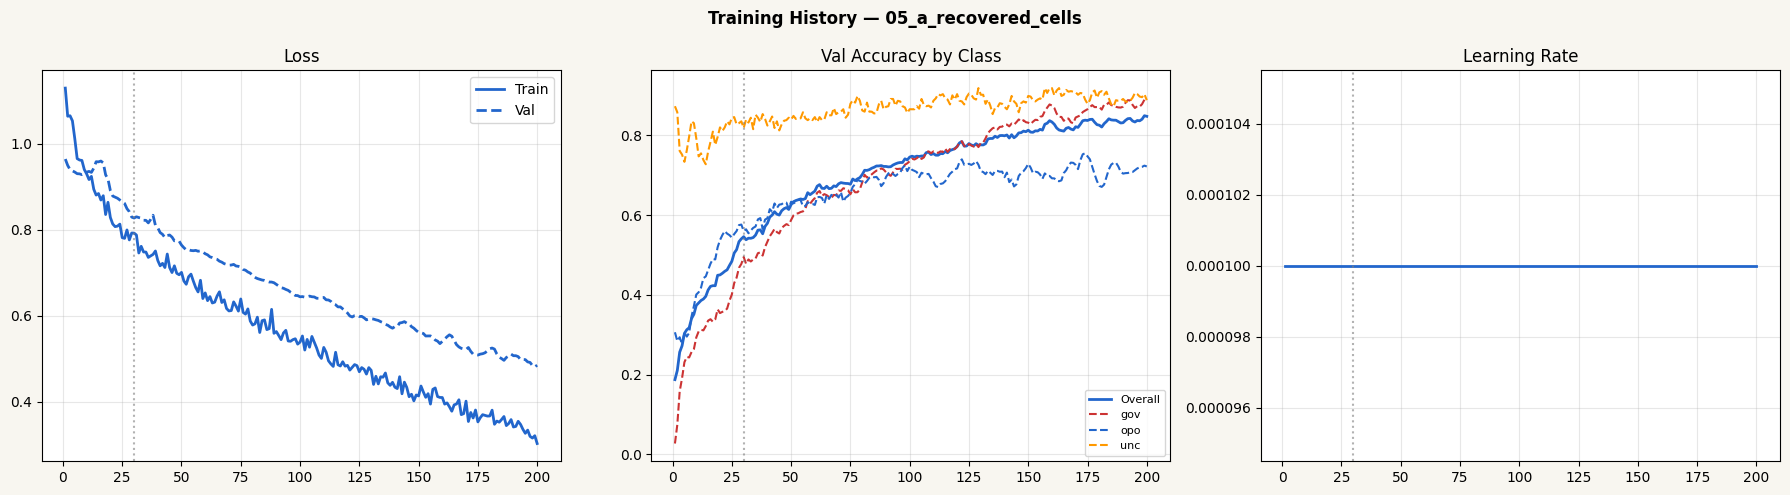

Training curve saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/05_a_recovered_cells/training_curves.png


In [9]:
# ── CELL 8: Training Curve ────────────────────────────────────────────────────
OUT_DIR_EXP = MODELS_DIR / EXPERIMENT_NAME
OUT_DIR_EXP.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#F8F6F0')
fig.suptitle(f'Training History — {EXPERIMENT_NAME}', fontsize=12, fontweight='bold')

epochs = range(1, len(history_exp['train_loss']) + 1)
col = '#2266CC'

ax = axes[0]
ax.plot(epochs, history_exp['train_loss'], color=col, lw=2, label='Train')
ax.plot(epochs, history_exp['val_loss'],   color=col, lw=2, ls='--', label='Val')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Loss'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, history_exp['val_acc'],          color=col, lw=2,   label='Overall')
ax.plot(epochs, history_exp['val_acc_gov'],       color='#CC3333', lw=1.5, ls='--', label='gov')
ax.plot(epochs, history_exp['val_acc_opo'],       color='#2266CC', lw=1.5, ls='--', label='opo')
ax.plot(epochs, history_exp['val_acc_uncertain'], color='#FF9900', lw=1.5, ls='--', label='unc')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Val Accuracy by Class'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(epochs, history_exp['lr'], color=col, lw=2)
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Learning Rate'); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR_EXP / 'training_curves.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curve saved: {fig_path}')


In [10]:
# ── CELL EXPORT: Save predictions to CSV ──────────────────────────────────────
import torch.nn.functional as F_export

OUT_DIR_EXP = MODELS_DIR / EXPERIMENT_NAME
OUT_DIR_EXP.mkdir(parents=True, exist_ok=True)

model_exp.eval()
all_pred_rows = []

with torch.no_grad():
    for i_m, month in enumerate(month_keys):
        X_t    = torch.from_numpy(X_array[i_m]).unsqueeze(0).to(DEVICE)
        logits = model_exp(X_t)
        probs  = F_export.softmax(logits, dim=1)[0].cpu().numpy()  # (3, H, W)
        preds  = logits.argmax(dim=1)[0].cpu().numpy()              # (H, W)

        month_rows = labelled[labelled['year_month'] == month]
        for _, row in month_rows.iterrows():
            gid = row['priogrid_gid']
            if gid not in gid_to_local: continue
            lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
            pred_int = int(preds[lr, lc])
            all_pred_rows.append({
                'priogrid_gid'   : int(gid),
                'year_month'     : month,
                'pred_class'     : INV_LABEL[pred_int],
                'pred_class_int' : pred_int,
                'prob_gov'       : float(probs[0, lr, lc]),
                'prob_opo'       : float(probs[1, lr, lc]),
                'prob_uncertain' : float(probs[2, lr, lc]),
                'confidence'     : float(probs[:, lr, lc].max()),
                'true_class'     : row['target'],
                'has_label'      : True,
                'is_train_month' : month <= TRAIN_CUTOFF,
            })

pred_csv = pd.DataFrame(all_pred_rows)
pred_path = OUT_DIR_EXP / 'predictions.csv'
pred_csv.to_csv(pred_path, index=False)
print(f'Predictions saved: {pred_path}  ({len(pred_csv):,} rows)')
print(f'Val rows: {(pred_csv["is_train_month"] == False).sum():,}')


Predictions saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/05_a_recovered_cells/predictions.csv  (5,180 rows)
Val rows: 2,562
